# D²NN 多任务光学分类 — 完整可复现实验（开源版 v3）

一次从零跑完，产出论文全部数据、模型、图与开源材料。相对早期版本，本版把此前所有故障点固化修复：

- **模型必存且当场校验**：每个配置训练后立即 `torch.save`，随即 `load` 回来验证文件可读、精度一致——杜绝"JSON 有记录但 .pt 缺失"。
- **单一 seed 主线 + 多 seed 统计**：正文数字全部来自 `MAIN_SEED=42` 的模型 checkpoint；`STAT_SEEDS` 仅用于补充材料 Table S1 的 mean±std。
- **训练量对齐**：多任务训练对短数据集循环采样、`steps=max`，消除 4-task 欠训练混淆。
- **目录自锚定**：Cell 0 自动定位/固定工作目录，文件放在哪、叫什么名都能跑。
- **断点续跑**：已完成的 (config, seed) 自动跳过；中断后重跑本 notebook 即从断点继续。
- **论文-代码一致**：T=0.1、λ_E=1e-3、ε=1e-6、USPS 980 nm、EMNIST A–J 十类、协议描述均与代码严格一致。

**运行方式**：菜单 `Kernel → Restart Kernel and Run All Cells`。全程无人值守；首次从零训练约 3–5 小时（取决于 GPU），含 5 seeds。只想先看主结果：把 Cell 2 的 `STAT_SEEDS=[]`，只跑 seed 42，约 40–60 分钟。

**开源产物**（跑完自动生成于工作目录）：`all_results.json`、`saved_models/*.pt`、`saved_samples/*.npz`、`robustness_results.json`、`paper_figures/`、`height_profile_B_seed42_um.npy`、`README.md`、`requirements.txt`。


## 0. 工作目录自锚定（第一格，务必最先运行）

In [1]:
# ==================== Cell 0: 自动锚定工作目录 ====================
import os, json
CACHE = os.path.join(os.path.expanduser('~'), '.d2nn_workdir.txt')

def _valid(p):
    return os.path.isfile(os.path.join(p, 'all_results.json')) or \
           os.path.isdir(os.path.join(p, 'saved_models'))

target = None
# 1) 缓存
if os.path.isfile(CACHE):
    p = open(CACHE, encoding='utf-8').read().strip()
    if os.path.isdir(p):
        target = p
# 2) 当前目录已有产物
if target is None and _valid(os.getcwd()):
    target = os.getcwd()
# 3) 搜索用户目录
if target is None:
    home = os.path.expanduser('~')
    SKIP = {'AppData','miniconda3','anaconda3','envs','node_modules','__pycache__',
            'site-packages','.git','.conda','.cache','.vscode','Windows','Program Files'}
    best = None
    for root, dirs, files in os.walk(home):
        dirs[:] = [d for d in dirs if d not in SKIP and not d.startswith('.')]
        if root[len(home):].count(os.sep) >= 6:
            dirs[:] = []
        if 'all_results.json' in files or 'saved_models' in dirs:
            best = root; break
    target = best
# 4) 都没有 -> 用当前目录全新开始
if target is None:
    target = os.getcwd()
    print('未发现历史产物，将在当前目录全新开始训练：')

os.chdir(target)
with open(CACHE, 'w', encoding='utf-8') as f:
    f.write(target)
print('工作目录 =', os.getcwd())
print('  all_results.json:', os.path.isfile('all_results.json'),
      '| saved_models/:', os.path.isdir('saved_models'))


工作目录 = C:\Users\HSY\Downloads\backup_0708
  all_results.json: True | saved_models/: True


## 1. 环境与超参

In [2]:
# ==================== Cell 1: 导入 ====================
import numpy as np, matplotlib.pyplot as plt
import os, time, json, random, ssl
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
ssl._create_default_https_context = ssl._create_unverified_context
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import transforms
import torchvision

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device, '|', torch.cuda.get_device_name(0) if device.type=='cuda' else 'CPU')
print('PyTorch', torch.__version__)


Device: cuda | NVIDIA GeForce RTX 5060 Laptop GPU
PyTorch 2.8.0+cu128


In [3]:
# ==================== Cell 2: 全局超参 ====================
# 光学 / 网格
IMG_SIZE, N_PIXELS = 168, 200
PAD = (N_PIXELS - IMG_SIZE)//2
DET_SIZE = 100
DET_OFFSET = (N_PIXELS - DET_SIZE)//2
PIXEL_SIZE = 8e-6            # 8 um
DISTANCE   = 0.05           # 5 cm
REFRACTIVE_INDEX, BACKGROUND_INDEX = 1.50, 1.00
MAX_THICKNESS = 2.2e-6      # 2.2 um

# 训练
TEMPERATURE = 0.1           # 论文 T；与 Wang(2026) 一致
EPS_DIFF    = 1e-6          # Eq.(5) 分母
LAM_E       = 1e-3          # Eq.(6) 能量项权重
EPOCHS      = 30
LR          = 0.005
BATCH_SIZE  = 32

# 种子：正文用 MAIN_SEED；STAT_SEEDS 供 Table S1（不想跑统计就设 []）
MAIN_SEED  = 42
STAT_SEEDS = [2026, 1234, 7, 999]
ALL_SEEDS  = [MAIN_SEED] + STAT_SEEDS

# 波长对（nm）
DIFF_WL = {
    'mnist':   {'pos':1064e-9, 'neg':532e-9},
    'fashion': {'pos':780e-9,  'neg':633e-9},
    'emnist':  {'pos':850e-9,  'neg':450e-9},
    'usps':    {'pos':980e-9,  'neg':488e-9},
}
SINGLE_WL = {'mnist':532e-9, 'fashion':1064e-9}
WL_PAIR = {t: sorted([v['pos'], v['neg']]) for t,v in DIFF_WL.items()}

ALL_WL_2 = [532e-9, 1064e-9]
ALL_WL_4 = [532e-9, 633e-9, 780e-9, 1064e-9]
ALL_WL_6 = [450e-9, 532e-9, 633e-9, 780e-9, 850e-9, 1064e-9]
ALL_WL_8 = [450e-9, 488e-9, 532e-9, 633e-9, 780e-9, 850e-9, 980e-9, 1064e-9]

MODEL_DIR, SAMPLE_DIR = 'saved_models', 'saved_samples'
RESULT_FILE, ROBUST_FILE = 'all_results.json', 'robustness_results.json'
FIG_DIR = 'paper_figures'
for d in (MODEL_DIR, SAMPLE_DIR, FIG_DIR):
    os.makedirs(d, exist_ok=True)

def set_seed(s):
    random.seed(s); np.random.seed(s); torch.manual_seed(s)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(s)

print('超参就绪 | 种子:', ALL_SEEDS)


超参就绪 | 种子: [42, 2026, 1234, 7, 999]


In [4]:
# ==================== Cell 3: 数据集 ====================
tf = transforms.Compose([transforms.ToTensor(),
     transforms.Resize((IMG_SIZE, IMG_SIZE),
        interpolation=transforms.InterpolationMode.NEAREST)])

train_mnist   = torchvision.datasets.MNIST('./data', True,  transform=tf, download=True)
val_mnist     = torchvision.datasets.MNIST('./data', False, transform=tf, download=True)
train_fashion = torchvision.datasets.FashionMNIST('./data', True,  transform=tf, download=True)
val_fashion   = torchvision.datasets.FashionMNIST('./data', False, transform=tf, download=True)

class LabelShift(torch.utils.data.Dataset):
    def __init__(self, ds): self.ds = ds
    def __len__(self): return len(self.ds)
    def __getitem__(self, i):
        x, y = self.ds[i]; return x, y - 1     # EMNIST letters 1..26 -> 0..25

_tre = torchvision.datasets.EMNIST('./data','letters',train=True, transform=tf,download=True)
_vae = torchvision.datasets.EMNIST('./data','letters',train=False,transform=tf,download=True)
tr_idx = [i for i,(_,y) in enumerate(_tre) if y <= 10]   # A-J
va_idx = [i for i,(_,y) in enumerate(_vae) if y <= 10]
train_emnist = LabelShift(Subset(_tre, tr_idx))
val_emnist   = LabelShift(Subset(_vae, va_idx))

train_usps = torchvision.datasets.USPS('./data', True,  transform=tf, download=True)
val_usps   = torchvision.datasets.USPS('./data', False, transform=tf, download=True)

def L(ds, sh): return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=sh)
TRAIN_LOADERS = {'mnist':L(train_mnist,1),'fashion':L(train_fashion,1),
                 'emnist':L(train_emnist,1),'usps':L(train_usps,1)}
VAL_LOADERS   = {'mnist':L(val_mnist,0),'fashion':L(val_fashion,0),
                 'emnist':L(val_emnist,0),'usps':L(val_usps,0)}
for k in TRAIN_LOADERS:
    print(f'{k:8s} train={len(TRAIN_LOADERS[k].dataset):6d}  test={len(VAL_LOADERS[k].dataset):5d}  '
          f'{len(TRAIN_LOADERS[k])} steps/epoch')


mnist    train= 60000  test=10000  1875 steps/epoch
fashion  train= 60000  test=10000  1875 steps/epoch
emnist   train= 48000  test= 8000  1500 steps/epoch
usps     train=  7291  test= 2007  228 steps/epoch


In [5]:
# ==================== Cell 4: 检测窗口 (3-4-3) ====================
win_h = win_w = 18
gap_x = 5
det_windows = []
for cnt, y0 in [(3,5),(4,31),(3,57)]:
    sx = (DET_SIZE - cnt*win_w - (cnt-1)*gap_x)//2
    for i in range(cnt):
        x1 = sx + i*(win_w+gap_x)
        det_windows.append((y0, y0+win_h, x1, x1+win_w))
assert len(det_windows) == 10

def partition_windows(w):
    m, f = [], []
    for y1,y2,x1,x2 in w:
        mid=(y1+y2)//2; m.append((y1,mid,x1,x2)); f.append((mid,y2,x1,x2))
    return m, f
mnist_win_part, fashion_win_part = partition_windows(det_windows)
print('10 windows, 18x18 px = 144x144 um')


10 windows, 18x18 px = 144x144 um


In [6]:
# ==================== Cell 5: 物理网络与算子 ====================
# 角谱传播 H=exp(i kz d), kz=sqrt((2pi)^2(1/lam^2 - fx^2 - fy^2))；相位 phi=(2pi/lam)(n-1)t
class ASProp(torch.nn.Module):
    def __init__(self, wls, N=200, dx=8e-6, dz=0.05):
        super().__init__()
        self.H = {}
        fx = np.fft.fftshift(np.fft.fftfreq(N, d=dx))
        fxx, fyy = np.meshgrid(fx, fx)
        for wl in wls:
            arg = (2*np.pi)**2 * ((1/wl)**2 - fxx**2 - fyy**2)
            t = np.sqrt(np.abs(arg))
            kz = np.where(arg>=0, t, 1j*t)
            self.H[wl] = torch.as_tensor(np.exp(1j*kz*dz), dtype=torch.complex64).to(device)
    def forward(self, E, wl):
        s = torch.fft.fftshift(torch.fft.fft2(E))
        return torch.fft.ifft2(torch.fft.ifftshift(s * self.H[wl]))

class D2NN(torch.nn.Module):
    def __init__(self, num_layers, wavelengths, N=200, dx=8e-6, dz=0.05):
        super().__init__()
        self.num_layers = num_layers
        self.n, self.n_bg, self.tmax = REFRACTIVE_INDEX, BACKGROUND_INDEX, MAX_THICKNESS
        for i in range(num_layers):
            self.register_parameter(f'thickness_{i}',
                torch.nn.Parameter(torch.randn(N,N)*0.1))
        self.props = torch.nn.ModuleList([ASProp(wavelengths,N,dx,dz) for _ in range(num_layers)])
        self.prop_det = ASProp(wavelengths,N,dx,dz)
    def phase(self, t, wl): return (2*np.pi/wl)*(self.n-self.n_bg)*t
    def forward(self, E, wl):
        for i in range(self.num_layers):
            E = self.props[i](E, wl)
            t = self.tmax*torch.sigmoid(getattr(self, f'thickness_{i}'))
            E = E*torch.exp(1j*self.phase(t, wl))
        return self.prop_det(E, wl)

def preprocess(imgs):
    x = imgs.squeeze(1); x = F.pad(x, [PAD]*4)
    return torch.sqrt(x+1e-8).to(torch.complex64)

def get_det(model, amp, wl):
    I = torch.abs(model(amp, wl))**2
    return I[:, DET_OFFSET:DET_OFFSET+DET_SIZE, DET_OFFSET:DET_OFFSET+DET_SIZE]

def diff_scores(Ip, In, wins, T=TEMPERATURE, eps=EPS_DIFF):
    out=[]
    for y1,y2,x1,x2 in wins:
        a=Ip[:,y1:y2,x1:x2].sum((1,2)); b=In[:,y1:y2,x1:x2].sum((1,2))
        out.append((a-b)/(a+b+eps)/T)
    return torch.stack(out,1)

def win_ints(I, wins):
    return torch.stack([I[:,y1:y2,x1:x2].sum((1,2)) for y1,y2,x1,x2 in wins],1)

def energy_loss(I, wins):
    e = sum(I[:,y1:y2,x1:x2].sum() for y1,y2,x1,x2 in wins)
    return (1 - e/(I.sum()+1e-8))**2
print('网络就绪 (单层参数量 = %d)' % (N_PIXELS*N_PIXELS))


网络就绪 (单层参数量 = 40000)


## 2. 训练引擎（模型必存并当场校验）

In [7]:
# ==================== Cell 6: 训练 / 评估 / 存取 ====================
def endless(loader):
    while True:
        yield from loader

def task_loss(model, mode, t, imgs, labs):
    amp = preprocess(imgs)
    if mode=='diff':
        Ip=get_det(model,amp,DIFF_WL[t]['pos']); In=get_det(model,amp,DIFF_WL[t]['neg'])
        return F.cross_entropy(diff_scores(Ip,In,det_windows), labs) + \
               LAM_E*(energy_loss(Ip,det_windows)+energy_loss(In,det_windows))
    if mode=='single':
        I=get_det(model,amp,SINGLE_WL[t]); lg=win_ints(I,det_windows)
        return F.cross_entropy(lg/(lg.sum(1,keepdim=True)+1e-8), labs)+LAM_E*energy_loss(I,det_windows)
    if mode=='single_partitioned':
        I=get_det(model,amp,SINGLE_WL[t]); w=mnist_win_part if t=='mnist' else fashion_win_part
        lg=win_ints(I,w); return F.cross_entropy(lg/(lg.sum(1,keepdim=True)+1e-8), labs)+LAM_E*energy_loss(I,w)

@torch.no_grad()
def task_pred(model, mode, t, imgs):
    amp=preprocess(imgs)
    if mode=='diff':
        return diff_scores(get_det(model,amp,DIFF_WL[t]['pos']),
                           get_det(model,amp,DIFF_WL[t]['neg']), det_windows).argmax(1)
    if mode=='single':
        return win_ints(get_det(model,amp,SINGLE_WL[t]), det_windows).argmax(1)
    if mode=='single_partitioned':
        w=mnist_win_part if t=='mnist' else fashion_win_part
        return win_ints(get_det(model,amp,SINGLE_WL[t]), w).argmax(1)

@torch.no_grad()
def evaluate(model, mode, t):
    model.eval(); c=n=0
    for imgs,labs in VAL_LOADERS[t]:
        imgs,labs=imgs.to(device),labs.to(device)
        c+=(task_pred(model,mode,t,imgs)==labs).sum().item(); n+=labs.size(0)
    return 100*c/n

def train_one(name, nl, wls, mode, tasks, seed):
    set_seed(seed)
    model=D2NN(nl, wls, N_PIXELS, PIXEL_SIZE, DISTANCE).to(device)
    opt=torch.optim.Adam(model.parameters(), lr=LR)
    sch=torch.optim.lr_scheduler.StepLR(opt, step_size=5, gamma=0.5)
    steps=max(len(TRAIN_LOADERS[t]) for t in tasks)
    hist={'loss':[], 'steps_per_epoch':steps}
    for t in tasks: hist[t]=[]
    t0=time.time()
    for ep in range(EPOCHS):
        model.train(); it={t:endless(TRAIN_LOADERS[t]) for t in tasks}; el=0
        for _ in range(steps):
            opt.zero_grad(); tot=torch.tensor(0.,device=device)
            for t in tasks:
                imgs,labs=next(it[t]); tot=tot+task_loss(model,mode,t,imgs.to(device),labs.to(device))
            tot.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(),1.0)
            opt.step(); el+=tot.item()
        sch.step(); hist['loss'].append(el/steps)
        for t in tasks: hist[t].append(evaluate(model,mode,t))
    return model, hist, sum(p.numel() for p in model.parameters() if p.requires_grad), time.time()-t0

def save_and_verify(model, name, seed, cfg, tasks):
    """存 .pt 并立即 load 回来验证可读——彻底杜绝“记录有、文件缺”。"""
    path=f'{MODEL_DIR}/{name}_seed{seed}.pt'
    torch.save({'state_dict':model.state_dict(),'config':cfg,'seed':seed}, path)
    ck=torch.load(path, map_location=device, weights_only=False)
    m2=D2NN(cfg['num_layers'], cfg['wavelengths'], N_PIXELS, PIXEL_SIZE, DISTANCE).to(device)
    m2.load_state_dict(ck['state_dict'])       # 读不回来会在此抛错
    assert os.path.getsize(path) > 1000, '存盘异常'
    return path

def load_model(name, seed=MAIN_SEED):
    ck=torch.load(f'{MODEL_DIR}/{name}_seed{seed}.pt', map_location=device, weights_only=False)
    m=D2NN(ck['config']['num_layers'], ck['config']['wavelengths'],
           N_PIXELS, PIXEL_SIZE, DISTANCE).to(device)
    m.load_state_dict(ck['state_dict']); m.eval(); return m, ck
print('训练引擎就绪（save_and_verify 保证每个 .pt 落盘且可读）')


训练引擎就绪（save_and_verify 保证每个 .pt 落盘且可读）


## 3. 全部实验（断点续跑；模型+样本+结果三者同时落盘）

In [8]:
# ==================== Cell 7: 实验清单 ====================
EXPERIMENTS = [
    ('A',         5, ALL_WL_2,         'single',              ['mnist','fashion']),
    ('A+',        5, ALL_WL_2,         'single_partitioned',  ['mnist','fashion']),
    ('B',         1, ALL_WL_4,         'diff',                ['mnist','fashion']),
    ('C',         2, ALL_WL_4,         'diff',                ['mnist','fashion']),
    ('D',         1, ALL_WL_2,         'single',              ['mnist','fashion']),
    ('E',         5, ALL_WL_4,         'diff',                ['mnist','fashion']),
    ('F-M',       1, WL_PAIR['mnist'], 'diff',                ['mnist']),
    ('F-F',       1, WL_PAIR['fashion'],'diff',               ['fashion']),
    ('3Task-cyc', 1, ALL_WL_6,         'diff',                ['mnist','fashion','emnist']),
    ('4Task-cyc', 1, ALL_WL_8,         'diff',                ['mnist','fashion','emnist','usps']),
]
# 每个配置画 Fig.2 用的可视化样本，仅 MAIN_SEED 存一次
def grab(loader, n=8):
    x,y = next(iter(loader)); return x[:n].clone(), y[:n].clone()
print(len(EXPERIMENTS), '个配置 x', len(ALL_SEEDS), '个 seed =', len(EXPERIMENTS)*len(ALL_SEEDS), 'runs')


10 个配置 x 5 个 seed = 50 runs


In [9]:
# ==================== Cell 8: 主训练循环 ====================
all_results = {}
if os.path.isfile(RESULT_FILE):
    all_results = json.load(open(RESULT_FILE, encoding='utf-8'))
    print('续跑：已载入', len(all_results), '个配置的历史结果')

VIS = {t: grab(VAL_LOADERS[t]) for t in DIFF_WL}
t_all = time.time()

for name, nl, wls, mode, tasks in EXPERIMENTS:
    ent = all_results.setdefault(name, {
        'name':name,'layers':nl,'wls':len(wls),
        'wavelengths_nm':[int(w*1e9) for w in wls],
        'mode':mode,'tasks':tasks,'runs':[]})
    done = {r['seed'] for r in ent['runs']}
    todo = [s for s in ALL_SEEDS if s not in done]
    # 即使 run 记录在，也确认 MAIN_SEED 的 .pt 真实存在（修复历史缺档）
    if MAIN_SEED in done and not os.path.isfile(f'{MODEL_DIR}/{name}_seed{MAIN_SEED}.pt'):
        ent['runs'] = [r for r in ent['runs'] if r['seed'] != MAIN_SEED]
        todo = [MAIN_SEED] + [s for s in todo if s != MAIN_SEED]
        print(f'  [{name}] seed{MAIN_SEED} 缺 .pt，将重训该 seed')
    if not todo:
        print(f'  [{name}] 已完成，跳过'); continue

    print(f'\n### {name}: {nl}L {len(wls)}wl {mode} {tasks}  待跑 {todo}')
    cfg = {'name':name,'num_layers':nl,'wavelengths':[float(w) for w in wls],
           'mode':mode,'tasks':tasks}
    for seed in todo:
        model, hist, nparams, sec = train_one(name, nl, wls, mode, tasks, seed)
        path = save_and_verify(model, name, seed, cfg, tasks)     # 存盘+校验
        rec = {'seed':seed, 'time_min':sec/60, 'n_params':nparams, 'history':hist}
        for t in tasks:
            rec[f'{t}_acc'] = float(hist[t][-1])       # 论文口径：末 epoch = checkpoint 精度
        ent['runs'].append(rec); ent['n_params']=nparams
        json.dump(all_results, open(RESULT_FILE,'w',encoding='utf-8'), indent=2, default=str)

        if seed == MAIN_SEED and mode == 'diff':       # 存 Fig.2 样本
            sd={}; model.eval()
            with torch.no_grad():
                for t in tasks:
                    x,y=VIS[t]; amp=preprocess(x.to(device))
                    sd[f'{t}_imgs']=x.numpy(); sd[f'{t}_labels']=y.numpy()
                    sd[f'{t}_Ipos']=get_det(model,amp,DIFF_WL[t]['pos']).cpu().numpy()
                    sd[f'{t}_Ineg']=get_det(model,amp,DIFF_WL[t]['neg']).cpu().numpy()
            np.savez_compressed(f'{SAMPLE_DIR}/{name}_seed{MAIN_SEED}_samples.npz', **sd)
        acc=' '.join(f'{t}={rec[f"{t}_acc"]:.2f}' for t in tasks)
        print(f'  seed{seed}: {acc}  ({sec/60:.1f}min)  -> {path}')

print(f'\n=== 全部完成，用时 {(time.time()-t_all)/60:.1f} min ===')


续跑：已载入 12 个配置的历史结果
  [A] 已完成，跳过
  [A+] 已完成，跳过
  [B] 已完成，跳过
  [C] 已完成，跳过
  [D] 已完成，跳过
  [E] 已完成，跳过
  [F-M] 已完成，跳过
  [F-F] 已完成，跳过
  [3Task-cyc] 已完成，跳过
  [4Task-cyc] 已完成，跳过

=== 全部完成，用时 0.0 min ===


In [10]:
# ==================== Cell 9: 完整性自检 ====================
# 确认每个配置 MAIN_SEED 的 .pt 存在且可 load，精度与 JSON 记录一致
print('配置       .pt存在  可载入  精度(json vs 重载)')
R = json.load(open(RESULT_FILE, encoding='utf-8'))
ok = True
for name, nl, wls, mode, tasks in EXPERIMENTS:
    p = f'{MODEL_DIR}/{name}_seed{MAIN_SEED}.pt'
    exists = os.path.isfile(p)
    loadable = False; note = ''
    if exists:
        try:
            m, ck = load_model(name, MAIN_SEED)
            a_json = next(r['history'][tasks[0]][-1] for r in R[name]['runs'] if r['seed']==MAIN_SEED)
            a_re = evaluate(m, mode, tasks[0])
            loadable = abs(a_json - a_re) < 0.01
            note = f'{a_json:.2f} vs {a_re:.2f}'
        except Exception as e:
            note = str(e)[:40]
    flag = exists and loadable
    ok = ok and flag
    print(f'{name:10s} {"Y" if exists else "N":^7s} {"Y" if loadable else "N":^6s}  {note}')
print('\n' + ('全部通过 ✓ 可以出图、开源' if ok else '有配置未通过 —— 重跑 Cell 8 会自动补'))


配置       .pt存在  可载入  精度(json vs 重载)
A             Y      Y     86.34 vs 86.34
A+            Y      Y     87.65 vs 87.65
B             Y      Y     97.00 vs 97.00
C             Y      Y     97.69 vs 97.69
D             Y      Y     59.98 vs 59.98
E             Y      Y     98.41 vs 98.41
F-M           Y      Y     97.60 vs 97.60
F-F           Y      Y     89.52 vs 89.52
3Task-cyc     Y      Y     95.94 vs 95.94
4Task-cyc     Y      Y     95.59 vs 95.59

全部通过 ✓ 可以出图、开源


## 4. 论文数字与图（单一数据源：seed42 checkpoint）

In [11]:
# ==================== Cell 10: 画图样式 + 取数 ====================
plt.rcParams.update({'font.family':'serif','font.serif':['Times New Roman','DejaVu Serif'],
    'mathtext.fontset':'cm','font.size':12,'savefig.dpi':600,'savefig.bbox':'tight',
    'axes.linewidth':1.2,'xtick.direction':'in','ytick.direction':'in',
    'axes.spines.top':False,'axes.spines.right':False})

def load_R(): return json.load(open(RESULT_FILE, encoding='utf-8'))
def pval(R, name, task, seed=MAIN_SEED):
    return float(next(r for r in R[name]['runs'] if r['seed']==seed)[f'{task}_acc'])
def pstat(R, name, task):
    a=np.array([r[f'{task}_acc'] for r in R[name]['runs']]); return a.mean(), a.std(), len(a)
def savefig(n):
    plt.savefig(f'{FIG_DIR}/{n}.png'); plt.savefig(f'{FIG_DIR}/{n}.pdf'); print(f'  -> {FIG_DIR}/{n}')
print('绘图工具就绪')

# --- 终版口径：论文所有数字 = 末epoch(=checkpoint精度)，新旧字段名都兼容 ---
def _acc(r, task):
    return float(r['history'][task][-1])
def pval(R, name, task, seed=MAIN_SEED):
    return _acc(next(r for r in R[name]['runs'] if r['seed']==seed), task)
def pstat(R, name, task):
    a=np.array([_acc(r,task) for r in R[name]['runs']]); return a.mean(), a.std(), len(a)


绘图工具就绪


In [12]:
# ==================== Cell 11: 论文数字冻结表（复制进 Word，禁止手抄）====================
R = load_R()
MAP = {'A':'A','A+':'A+','B':'B','C':'C','D':'D','E':'E','F-M':'F-M','F-F':'F-F',
       'G':'3Task-cyc','H':'4Task-cyc'}
print(f'{"论文":<4}{"键":<11}{"task":<9}{"正文(seed42)":>13}{"Table S1 (mean±std)":>22}')
for p,j in MAP.items():
    if j not in R: continue
    for t in R[j]['tasks']:
        try: v=pval(R,j,t)
        except StopIteration: continue
        m,s,n=pstat(R,j,t)
        print(f'{p:<4}{j:<11}{t:<9}{v:>12.2f}%{m:>13.2f} ± {s:.2f}% (n={n})')
def d(a,b,t): return pval(R,b,t)-pval(R,a,t)
if '3Task-cyc' in R and '4Task-cyc' in R:
    print('\nN 标度 Δ (MNIST):', 
          f"1->2 {d('F-M','B','mnist'):+.2f}  2->3 {d('B','3Task-cyc','mnist'):+.2f}  "
          f"3->4 {d('3Task-cyc','4Task-cyc','mnist'):+.2f} pp")
print('\n关键对比:')
for t in ['mnist','fashion']:
    print(f'  {t}: B-A={d("A","B",t):+.2f}  B-A+={d("A+","B",t):+.2f}  '
          f'B-D={d("D","B",t):+.2f}  E-A={d("A","E",t):+.2f} pp')


论文  键          task        正文(seed42)   Table S1 (mean±std)
A   A          mnist           86.34%        86.37 ± 0.14% (n=5)
A   A          fashion         70.18%        70.27 ± 0.16% (n=5)
A+  A+         mnist           87.65%        87.68 ± 0.02% (n=5)
A+  A+         fashion         77.13%        77.08 ± 0.09% (n=5)
B   B          mnist           97.00%        96.93 ± 0.07% (n=5)
B   B          fashion         88.38%        88.50 ± 0.11% (n=5)
C   C          mnist           97.69%        97.75 ± 0.03% (n=5)
C   C          fashion         89.33%        89.39 ± 0.06% (n=5)
D   D          mnist           59.98%        60.51 ± 0.36% (n=5)
D   D          fashion         45.49%        44.79 ± 0.42% (n=5)
E   E          mnist           98.41%        98.42 ± 0.03% (n=5)
E   E          fashion         90.17%        90.07 ± 0.11% (n=5)
F-M F-M        mnist           97.60%        97.66 ± 0.06% (n=5)
F-F F-F        fashion         89.52%        89.44 ± 0.09% (n=5)
G   3Task-cyc  mnist          

mnist: true=7 pred=7 margin=6.32 eta+=27.0% eta-=24.4%
fashion: true=Boot pred=Boot margin=2.92 eta+=14.7% eta-=20.6%
  -> paper_figures/fig2_differential_readout


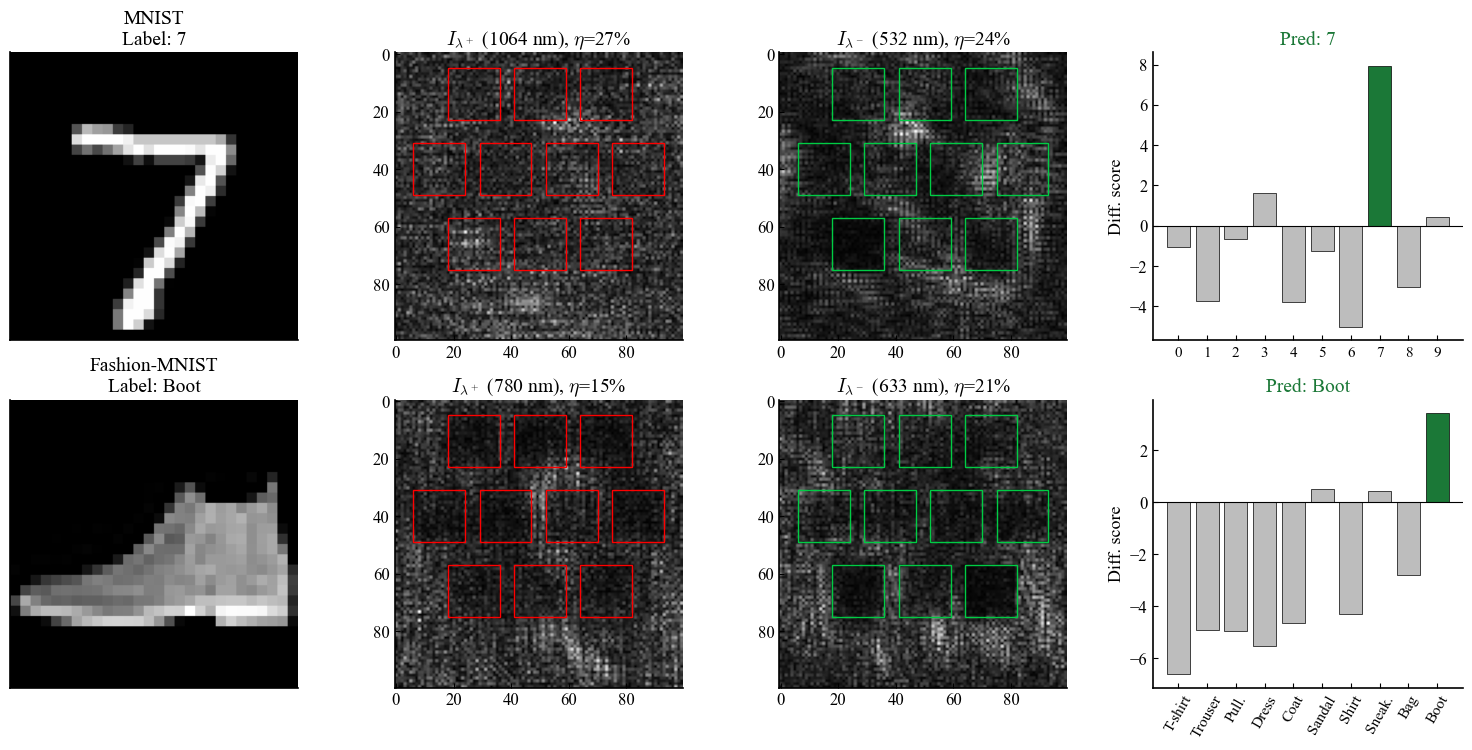

In [29]:
# ==================== Cell 12: Fig.2 差分读出 + η 诊断（4列 · 大字号版）====================
from matplotlib.patches import Rectangle
from matplotlib.colors import PowerNorm
WL={'mnist':('1064 nm','532 nm'),'fashion':('780 nm','633 nm')}
NAME={'mnist':'MNIST','fashion':'Fashion-MNIST'}
CLS={'mnist':[str(i) for i in range(10)],
     'fashion':['T-shirt','Trouser','Pull.','Dress','Coat','Sandal','Shirt','Sneak.','Bag','Boot']}
d=np.load(f'{SAMPLE_DIR}/B_seed{MAIN_SEED}_samples.npz')
GAMMA=0.6

def wscore(Ip,In):
    return np.array([(Ip[y1:y2,x1:x2].sum()-In[y1:y2,x1:x2].sum())/
                     (Ip[y1:y2,x1:x2].sum()+In[y1:y2,x1:x2].sum()+EPS_DIFF)/TEMPERATURE
                     for y1,y2,x1,x2 in det_windows])
def eta(A):
    return np.mean([sum(a[y1:y2,x1:x2].sum() for y1,y2,x1,x2 in det_windows)/a.sum() for a in A])

K={'mnist':0,'fashion':0}
fig,axes=plt.subplots(2,4,figsize=(15,7.6))
for r,task in enumerate(['mnist','fashion']):
    k=K[task]; img=d[f'{task}_imgs'][k,0]; lab=int(d[f'{task}_labels'][k])
    Ip,In=d[f'{task}_Ipos'][k],d[f'{task}_Ineg'][k]
    epp,enn=eta(d[f'{task}_Ipos']),eta(d[f'{task}_Ineg'])
    S=wscore(Ip,In); o=np.argsort(S)[::-1]; pred=int(o[0])
    print(f'{task}: true={CLS[task][lab]} pred={CLS[task][pred]} margin={S[o[0]]-S[o[1]]:.2f} '
          f'eta+={epp:.1%} eta-={enn:.1%}')
    a=axes[r]
    # (a) 输入
    a[0].imshow(img,cmap='gray')
    a[0].set_title(f'{NAME[task]}\nLabel: {CLS[task][lab]}',fontsize=14)
    a[0].set_xticks([]); a[0].set_yticks([])
    # (b,c) 强度图
    a[1].imshow(Ip,cmap='gray',norm=PowerNorm(GAMMA))
    a[1].set_title(r'$I_{\lambda^+}$ (%s), $\eta$=%.0f%%'%(WL[task][0],100*epp),fontsize=14)
    a[2].imshow(In,cmap='gray',norm=PowerNorm(GAMMA))
    a[2].set_title(r'$I_{\lambda^-}$ (%s), $\eta$=%.0f%%'%(WL[task][1],100*enn),fontsize=14)
    for y1,y2,x1,x2 in det_windows:
        a[1].add_patch(Rectangle((x1,y1),x2-x1,y2-y1,fill=False,ec='red',lw=1.0))
        a[2].add_patch(Rectangle((x1,y1),x2-x1,y2-y1,fill=False,ec='#00CC44',lw=1.0))
    for ax_ in a[1:3]:
        ax_.tick_params(labelsize=12)          # ← 强度图刻度放大
    # (d) 分数柱状图
    ok=(pred==lab)
    a[3].bar(range(10),S,color=['#1B7837' if i==lab else '#BDBDBD' for i in range(10)],
             edgecolor='k',lw=.5)
    a[3].set_title(f'Pred: {CLS[task][pred]}',fontsize=14,color='#1B7837' if ok else '#B2182B')
    a[3].axhline(0,color='k',lw=.8)
    a[3].set_ylabel('Diff. score',fontsize=13)  # ← 纵轴标签放大
    a[3].tick_params(axis='y',labelsize=12)     # ← 纵轴刻度放大
    a[3].set_xticks(range(10))
    a[3].set_xticklabels(CLS[task],rotation=60 if task=='fashion' else 0,fontsize=11)  # ← 类别标签放大
plt.tight_layout(); savefig('fig2_differential_readout'); plt.show()


  -> paper_figures/fig3_training_curves


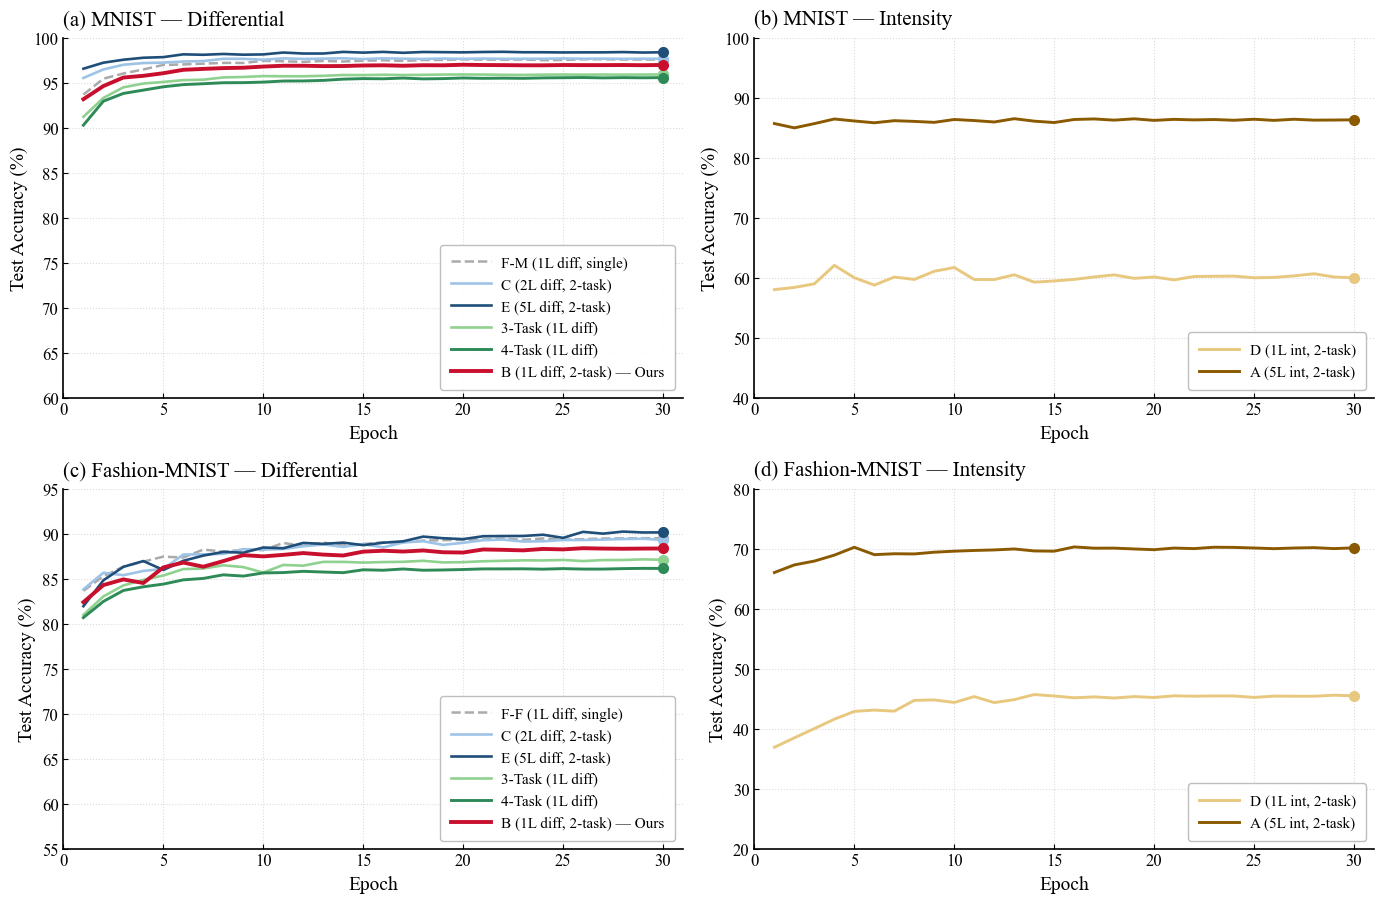

In [30]:
# ==================== Cell 13: Fig.3 训练曲线（2×2 · 大字号版）====================
R=load_R()
def H(name,task):
    return next(r for r in R[name]['runs'] if r['seed']==MAIN_SEED)['history'][task]
ep=np.arange(1,EPOCHS+1)

DIFF_M=[('F-M (1L diff, single)','F-M','mnist','#AAAAAA','--',1.8),
        ('C (2L diff, 2-task)','C','mnist','#9DC3E6','-',1.9),
        ('E (5L diff, 2-task)','E','mnist','#1F4E79','-',1.9),
        ('3-Task (1L diff)','3Task-cyc','mnist','#8FD18F','-',1.9),
        ('4-Task (1L diff)','4Task-cyc','mnist','#2E8B57','-',2.1),
        ('B (1L diff, 2-task) — Ours','B','mnist','#C8102E','-',2.8)]
DIFF_F=[('F-F (1L diff, single)','F-F','fashion','#AAAAAA','--',1.8),
        ('C (2L diff, 2-task)','C','fashion','#9DC3E6','-',1.9),
        ('E (5L diff, 2-task)','E','fashion','#1F4E79','-',1.9),
        ('3-Task (1L diff)','3Task-cyc','fashion','#8FD18F','-',1.9),
        ('4-Task (1L diff)','4Task-cyc','fashion','#2E8B57','-',2.1),
        ('B (1L diff, 2-task) — Ours','B','fashion','#C8102E','-',2.8)]
INT_M=[('D (1L int, 2-task)','D','mnist','#E8C87E','-',2.1),
       ('A (5L int, 2-task)','A','mnist','#8B5A00','-',2.1)]
INT_F=[('D (1L int, 2-task)','D','fashion','#E8C87E','-',2.1),
       ('A (5L int, 2-task)','A','fashion','#8B5A00','-',2.1)]

fig,axes=plt.subplots(2,2,figsize=(14,9.2))
def panel(ax,spec,title,ylim,yticks):
    for lab,cfg,task,c,ls,lw in spec:
        y=H(cfg,task); ax.plot(ep,y,ls,color=c,lw=lw,label=lab)
        ax.plot(EPOCHS,y[-1],'o',color=c,ms=7,zorder=5)
    ax.set_title(title,fontsize=15,loc='left',pad=10)
    ax.set_xlabel('Epoch',fontsize=14)
    ax.set_ylabel('Test Accuracy (%)',fontsize=14)
    ax.set_xlim(0,EPOCHS+1); ax.set_ylim(*ylim); ax.set_yticks(yticks)
    ax.set_xticks([0,5,10,15,20,25,30])
    ax.tick_params(labelsize=12)
    ax.grid(ls=':',alpha=0.45); ax.set_axisbelow(True)
    ax.legend(fontsize=11, loc='lower right', frameon=True, framealpha=0.95,
              edgecolor='#BBBBBB', handlelength=2.6, borderpad=0.7,
              labelspacing=0.5, handletextpad=0.7)

panel(axes[0,0],DIFF_M,'(a) MNIST — Differential',(60,100),[60,65,70,75,80,85,90,95,100])
panel(axes[0,1],INT_M ,'(b) MNIST — Intensity',(40,100),[40,50,60,70,80,90,100])
panel(axes[1,0],DIFF_F,'(c) Fashion-MNIST — Differential',(55,95),[55,60,65,70,75,80,85,90,95])
panel(axes[1,1],INT_F ,'(d) Fashion-MNIST — Intensity',(20,80),[20,30,40,50,60,70,80])
plt.tight_layout(); savefig('fig3_training_curves'); plt.show()

  -> paper_figures/fig4_N_scaling


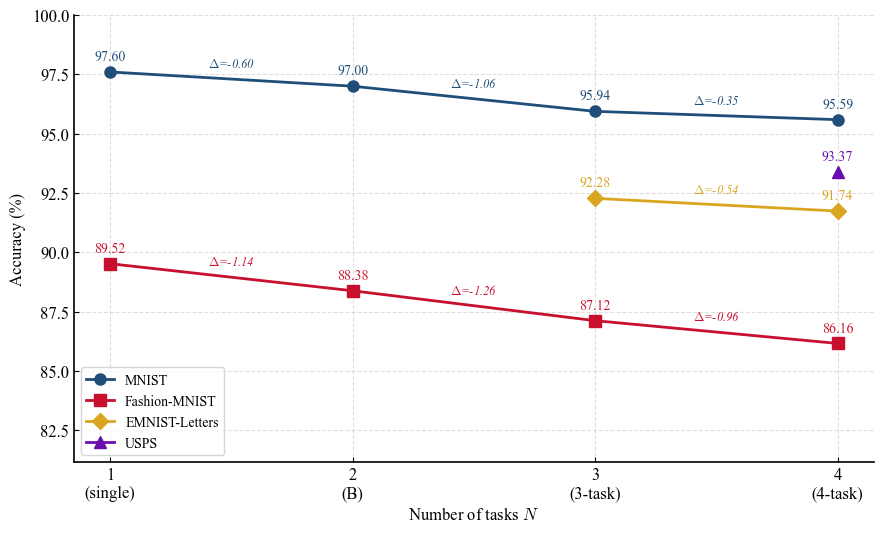

In [14]:
# ==================== Cell 14: Fig.4 任务数标度 ====================
R=load_R()
def series(task,cfgs):
    Ns,vs=[],[]
    for N,n in cfgs:
        if n in R and task in R[n]['tasks']: Ns.append(N); vs.append(pval(R,n,task))
    return np.array(Ns),np.array(vs)
S=[('MNIST','mnist',[(1,'F-M'),(2,'B'),(3,'3Task-cyc'),(4,'4Task-cyc')],'#1F4E79','o'),
   ('Fashion-MNIST','fashion',[(1,'F-F'),(2,'B'),(3,'3Task-cyc'),(4,'4Task-cyc')],'#C8102E','s'),
   ('EMNIST-Letters','emnist',[(3,'3Task-cyc'),(4,'4Task-cyc')],'#DAA520','D'),
   ('USPS','usps',[(4,'4Task-cyc')],'#6A0DAD','^')]
fig,ax=plt.subplots(figsize=(9,5.5)); ymin=100
for lab,t,cfgs,c,mk in S:
    N,m=series(t,cfgs)
    if len(N)==0: continue
    ymin=min(ymin,m.min()); ax.plot(N,m,marker=mk,ms=8,lw=2,color=c,label=lab)
    for ni,mi in zip(N,m): ax.text(ni,mi+.5,f'{mi:.2f}',ha='center',fontsize=10,color=c)
    for i in range(len(N)-1):
        ax.text((N[i]+N[i+1])/2,(m[i]+m[i+1])/2+.5,f'$\\Delta$={m[i+1]-m[i]:+.2f}',
                ha='center',fontsize=9,color=c,style='italic')
ax.set_xticks([1,2,3,4]); ax.set_xticklabels(['1\n(single)','2\n(B)','3\n(3-task)','4\n(4-task)'])
ax.set_xlabel('Number of tasks $N$'); ax.set_ylabel('Accuracy (%)')
ax.set_ylim(max(0,ymin-5),100); ax.legend(loc='lower left',fontsize=10); ax.grid(ls='--',alpha=.4)
plt.tight_layout(); savefig('fig4_N_scaling'); plt.show()


C:\Users\HSY\AppData\Local\Temp\ipykernel_13472\2001282567.py:35: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); savefig('fig6_cm_configB'); plt.show()


  -> paper_figures/fig6_cm_configB


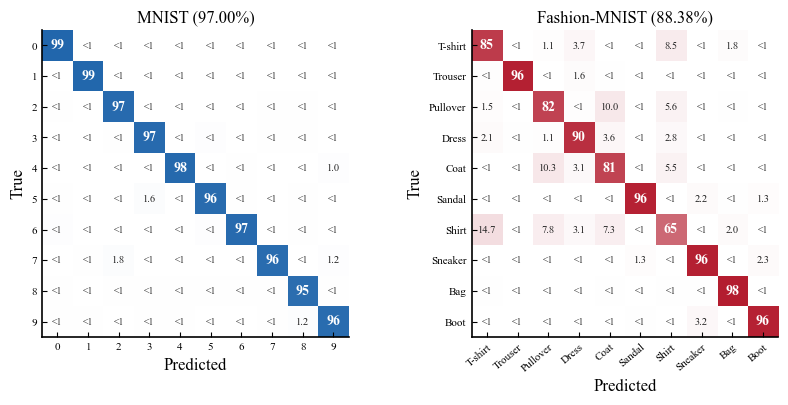

C:\Users\HSY\AppData\Local\Temp\ipykernel_13472\2001282567.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); savefig('fig5a_cm_3task'); plt.show()


  -> paper_figures/fig5a_cm_3task


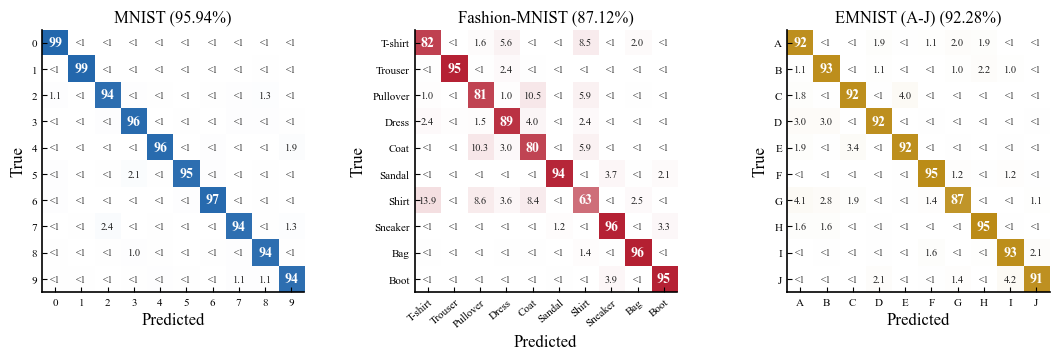

C:\Users\HSY\AppData\Local\Temp\ipykernel_13472\2001282567.py:43: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); savefig('fig5b_cm_4task'); plt.show()


  -> paper_figures/fig5b_cm_4task


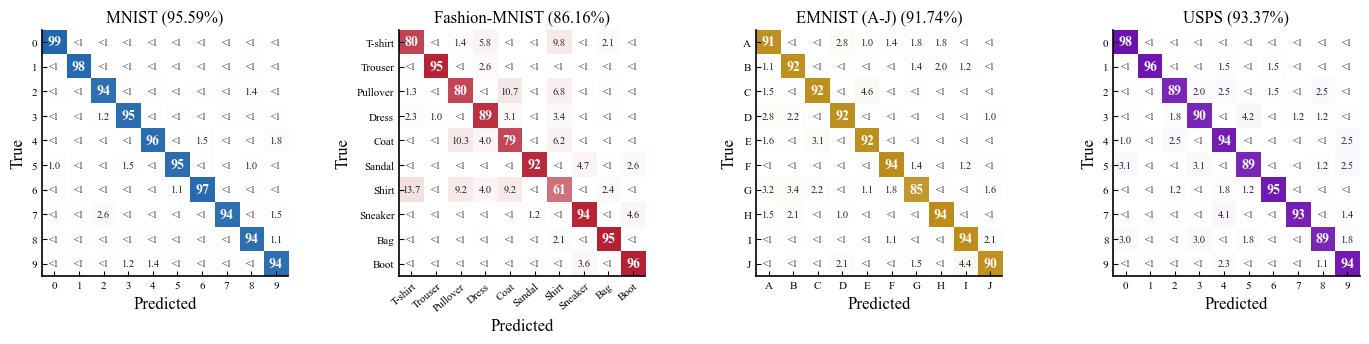

In [15]:
# ==================== Cell 15: 混淆矩阵工具 + Fig.5/6 ====================
from sklearn.metrics import confusion_matrix
from matplotlib.colors import LinearSegmentedColormap
CMLAB={'mnist':[str(i) for i in range(10)],
       'fashion':['T-shirt','Trouser','Pullover','Dress','Coat','Sandal','Shirt','Sneaker','Bag','Boot'],
       'emnist':list('ABCDEFGHIJ'),'usps':[str(i) for i in range(10)]}
CMAP={'mnist':LinearSegmentedColormap.from_list('c',['#fff','#2166AC']),
      'fashion':LinearSegmentedColormap.from_list('c',['#fff','#B2182B']),
      'emnist':LinearSegmentedColormap.from_list('c',['#fff','#B8860B']),
      'usps':LinearSegmentedColormap.from_list('c',['#fff','#6A0DAD'])}
@torch.no_grad()
def cm_pred(model,t):
    P,T=[],[]
    for imgs,labs in VAL_LOADERS[t]:
        P.append(task_pred(model,'diff',t,imgs.to(device)).cpu().numpy()); T.append(labs.numpy())
    return np.concatenate(P),np.concatenate(T)
def draw_cm(ax,model,t,title):
    p,tr=cm_pred(model,t); cm=confusion_matrix(tr,p); pct=100*cm/cm.sum(1,keepdims=True)
    acc=100*np.trace(cm)/cm.sum(); lab=CMLAB[t]
    ax.imshow(pct,cmap=CMAP[t],vmin=0,vmax=100); ax.set_xticks(range(10)); ax.set_yticks(range(10))
    rot=dict(rotation=40,ha='right',rotation_mode='anchor') if t=='fashion' else {}
    ax.set_xticklabels(lab,fontsize=8,**rot); ax.set_yticklabels(lab,fontsize=8)
    ax.set_title(f'{title} ({acc:.2f}%)',fontsize=12); ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    for i in range(10):
        for j in range(10):
            v=pct[i,j]
            if v<1: txt,fs,fw='<1',7,'normal'
            elif i==j: txt,fs,fw=f'{v:.0f}',10,'bold'
            else: txt,fs,fw=f'{v:.1f}',7.5,'normal'
            ax.text(j,i,txt,ha='center',va='center',fontsize=fs,fontweight=fw,color='w' if v>55 else '#222')
    return acc
# Fig.6 Config B
mB,_=load_model('B'); fig,ax=plt.subplots(1,2,figsize=(9.5,4.4),gridspec_kw={'wspace':.4})
for a,t,ti in zip(ax,['mnist','fashion'],['MNIST','Fashion-MNIST']): draw_cm(a,mB,t,ti)
plt.tight_layout(); savefig('fig6_cm_configB'); plt.show()
# Fig.5a 3-task
m3,_=load_model('3Task-cyc'); fig,ax=plt.subplots(1,3,figsize=(13,4.2),gridspec_kw={'wspace':.42})
for a,t,ti in zip(ax,['mnist','fashion','emnist'],['MNIST','Fashion-MNIST','EMNIST (A-J)']): draw_cm(a,m3,t,ti)
plt.tight_layout(); savefig('fig5a_cm_3task'); plt.show()
# Fig.5b 4-task
m4,_=load_model('4Task-cyc'); fig,ax=plt.subplots(1,4,figsize=(17,4.2),gridspec_kw={'wspace':.45})
for a,t,ti in zip(ax,['mnist','fashion','emnist','usps'],['MNIST','Fashion-MNIST','EMNIST (A-J)','USPS']): draw_cm(a,m4,t,ti)
plt.tight_layout(); savefig('fig5b_cm_4task'); plt.show()


导出 height_profile_B_seed42_um.npy


C:\Users\HSY\AppData\Local\Temp\ipykernel_13472\1897838709.py:20: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); savefig('fig10_height_phase'); plt.show()


  -> paper_figures/fig10_height_phase


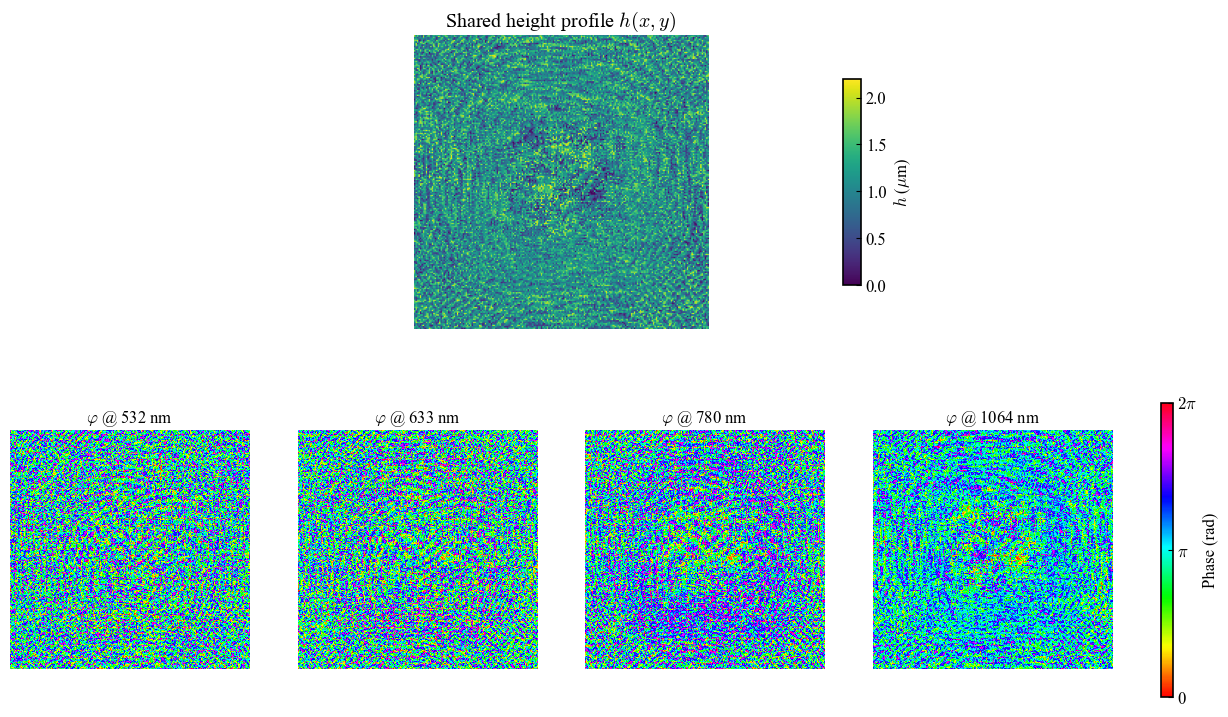

In [16]:
# ==================== Cell 16: Fig.10 高度图/相位图 + 导出 npy ====================
mB,_=load_model('B')
th=(MAX_THICKNESS*torch.sigmoid(mB.thickness_0.detach().cpu())).numpy()
np.save('height_profile_B_seed42_um.npy', th*1e6)
print('导出 height_profile_B_seed42_um.npy')
dn=REFRACTIVE_INDEX-BACKGROUND_INDEX
wls={'532 nm':532e-9,'633 nm':633e-9,'780 nm':780e-9,'1064 nm':1064e-9}
fig=plt.figure(figsize=(15,8.6))
gs=fig.add_gridspec(2,5,height_ratios=[1,1],width_ratios=[1,1,1,1,.05],hspace=.25,wspace=.25)
axh=fig.add_subplot(gs[0,1:3]); im0=axh.imshow(th*1e6,cmap='viridis',vmin=0,vmax=MAX_THICKNESS*1e6)
axh.set_title('Shared height profile $h(x,y)$'); axh.axis('off')
cax=fig.add_subplot(gs[0,3]); pp=cax.get_position()
cax.set_position([pp.x0-.02,pp.y0+pp.height*.15,.012,pp.height*.7])
fig.colorbar(im0,cax=cax).set_label(r'$h$ ($\mu$m)')
for i,(nm,wl) in enumerate(wls.items()):
    a=fig.add_subplot(gs[1,i]); ph=((2*np.pi/wl)*dn*th)%(2*np.pi)
    im=a.imshow(ph,cmap='hsv',vmin=0,vmax=2*np.pi); a.set_title(f'$\\varphi$ @ {nm}',fontsize=12); a.axis('off')
c1=fig.add_subplot(gs[1,4]); cb=fig.colorbar(im,cax=c1); cb.set_label('Phase (rad)')
cb.set_ticks([0,np.pi,2*np.pi]); cb.set_ticklabels(['0',r'$\pi$',r'$2\pi$'])
plt.tight_layout(); savefig('fig10_height_phase'); plt.show()


## 5. 鲁棒性实验（eval-only）

In [17]:
# ==================== Cell 17: 鲁棒性存档工具 ====================
def save_robust(key,data):
    st={}
    if os.path.isfile(ROBUST_FILE): st=json.load(open(ROBUST_FILE,encoding='utf-8'))
    st[key]=data; json.dump(st,open(ROBUST_FILE,'w',encoding='utf-8'),indent=2,default=str)
    print('  ->',ROBUST_FILE,'::',key)
print('就绪')


就绪


a=0.00 MNIST=97.00 Fashion=88.38
a=0.05 MNIST=96.63 Fashion=87.58
a=0.10 MNIST=95.85 Fashion=86.83
a=0.15 MNIST=94.64 Fashion=85.31
a=0.20 MNIST=91.62 Fashion=82.91
a=0.25 MNIST=86.60 Fashion=78.86
a=0.30 MNIST=80.24 Fashion=73.77
a=0.35 MNIST=70.77 Fashion=65.53
a=0.40 MNIST=61.51 Fashion=57.53
a=0.45 MNIST=51.04 Fashion=48.84
a=0.50 MNIST=41.68 Fashion=43.12
a=0.55 MNIST=31.95 Fashion=36.74
a=0.60 MNIST=24.62 Fashion=31.61
a=0.65 MNIST=20.25 Fashion=26.15
a=0.70 MNIST=16.51 Fashion=22.51
a=0.75 MNIST=14.37 Fashion=18.09
a=0.80 MNIST=12.71 Fashion=14.60
  -> robustness_results.json :: salt_pepper_B
  -> paper_figures/fig7_noise_robustness


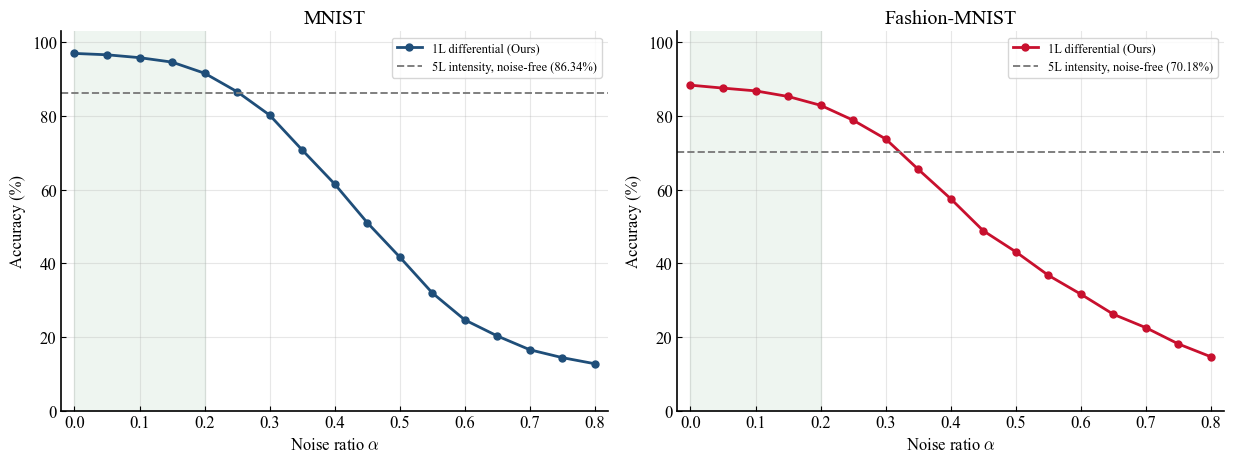

In [18]:
# ==================== Cell 18: Fig.7 盐椒噪声 ====================
def salt_pepper(x,a):
    n=torch.rand_like(x); y=x.clone(); y[n<a/2]=0; y[n>1-a/2]=1; return y
set_seed(0); mB,_=load_model('B'); R=load_R()
AL=np.round(np.arange(0,0.81,0.05),2); res={'mnist':[],'fashion':[]}
with torch.no_grad():
    for a in AL:
        for t in ['mnist','fashion']:
            c=n=0
            for imgs,labs in VAL_LOADERS[t]:
                imgs=salt_pepper(imgs,float(a)).to(device); labs=labs.to(device)
                c+=(task_pred(mB,'diff',t,imgs)==labs).sum().item(); n+=labs.size(0)
            res[t].append(100*c/n)
        print(f'a={a:.2f} MNIST={res["mnist"][-1]:.2f} Fashion={res["fashion"][-1]:.2f}')
save_robust('salt_pepper_B',{'alphas':[float(a) for a in AL],**res})
fig,ax=plt.subplots(1,2,figsize=(12.5,4.8))
for a,t,ti,c in [(ax[0],'mnist','MNIST','#1F4E79'),(ax[1],'fashion','Fashion-MNIST','#C8102E')]:
    bl=pval(R,'A',t)
    a.fill_betweenx([0,105],0,0.2,color='#1B7837',alpha=.07)
    a.plot(AL,res[t],'o-',color=c,lw=2,ms=5,label='1L differential (Ours)')
    a.axhline(bl,color='#7F7F7F',ls='--',lw=1.4,label=f'5L intensity, noise-free ({bl:.2f}%)')
    a.set(xlabel=r'Noise ratio $\alpha$',ylabel='Accuracy (%)',title=ti)
    a.set_ylim(0,103); a.set_xlim(-.02,.82); a.grid(alpha=.3); a.legend(fontsize=9)
plt.tight_layout(); savefig('fig7_noise_robustness'); plt.show()


sigma=0.00pi (0nm) MNIST=97.00 Fashion=88.38
sigma=0.05pi (27nm) MNIST=97.00 Fashion=88.35
sigma=0.10pi (53nm) MNIST=96.75 Fashion=87.82
sigma=0.15pi (80nm) MNIST=96.10 Fashion=85.49
sigma=0.20pi (106nm) MNIST=94.62 Fashion=82.14
sigma=0.25pi (133nm) MNIST=90.39 Fashion=78.32
sigma=0.30pi (160nm) MNIST=84.61 Fashion=70.78
  -> robustness_results.json :: height_perturbation_B
  -> paper_figures/fig8_fabrication_robustness


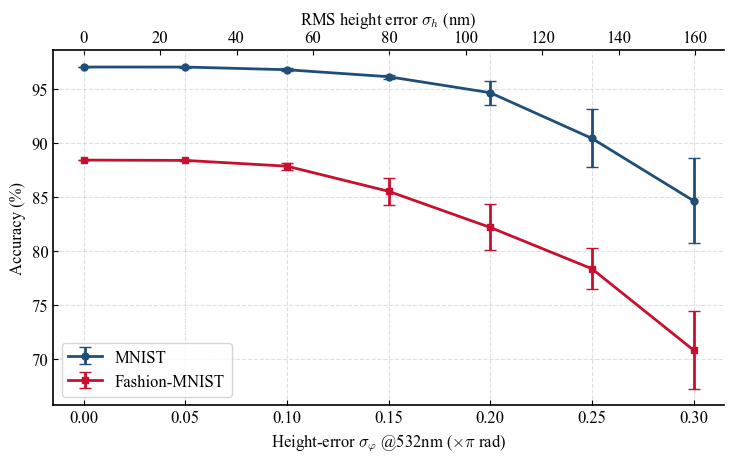

In [19]:
# ==================== Cell 19: Fig.8 加工误差（高度域扰动）====================
from copy import deepcopy
def perturb_height(model,sig_phi,lam_ref=532e-9):
    m=deepcopy(model)
    with torch.no_grad():
        for i in range(m.num_layers):
            raw=getattr(m,f'thickness_{i}'); t=MAX_THICKNESS*torch.sigmoid(raw)
            dn=REFRACTIVE_INDEX-BACKGROUND_INDEX; sh=sig_phi*lam_ref/(2*np.pi*dn)
            tn=torch.clamp(t+torch.randn_like(t)*sh,0,MAX_THICKNESS)
            rr=torch.clamp(tn/MAX_THICKNESS,1e-6,1-1e-6); raw.copy_(torch.log(rr/(1-rr)))
    return m
SIG=[0,0.05,0.1,0.15,0.2,0.25,0.3]; NT=10; dn=REFRACTIVE_INDEX-BACKGROUND_INDEX
set_seed(0); mB,_=load_model('B')
out={'sigma_pi':SIG,'mnist_mean':[],'mnist_std':[],'fashion_mean':[],'fashion_std':[]}
for s in SIG:
    tm,tf=[],[]
    for _ in range(NT if s>0 else 1):
        m=mB if s==0 else perturb_height(mB,s*np.pi).to(device)
        tm.append(evaluate(m,'diff','mnist')); tf.append(evaluate(m,'diff','fashion'))
        if s>0:
            del m
            torch.cuda.empty_cache() if torch.cuda.is_available() else None
    out['mnist_mean'].append(float(np.mean(tm))); out['mnist_std'].append(float(np.std(tm)))
    out['fashion_mean'].append(float(np.mean(tf))); out['fashion_std'].append(float(np.std(tf)))
    print(f'sigma={s:.2f}pi ({s*np.pi*532/(2*np.pi*dn):.0f}nm) MNIST={np.mean(tm):.2f} Fashion={np.mean(tf):.2f}')
save_robust('height_perturbation_B',out)
sig=np.array(SIG); fig,ax=plt.subplots(figsize=(7.5,4.8))
ax.errorbar(sig,out['mnist_mean'],out['mnist_std'],fmt='o-',color='#1F4E79',lw=2,ms=5,capsize=4,label='MNIST')
ax.errorbar(sig,out['fashion_mean'],out['fashion_std'],fmt='s-',color='#C8102E',lw=2,ms=5,capsize=4,label='Fashion-MNIST')
ax.set_xlabel(r'Height-error $\sigma_\varphi$ @532nm ($\times\pi$ rad)'); ax.set_ylabel('Accuracy (%)')
sec=ax.secondary_xaxis('top',functions=(lambda x:x*np.pi*532/(2*np.pi*dn),lambda h:h*(2*np.pi*dn)/(np.pi*532)))
sec.set_xlabel(r'RMS height error $\sigma_h$ (nm)'); ax.grid(ls='--',alpha=.4); ax.legend()
plt.tight_layout(); savefig('fig8_fabrication_robustness'); plt.show()


g=0.850 MNIST=97.00 Fashion=88.38
g=0.875 MNIST=97.00 Fashion=88.38
g=0.900 MNIST=97.00 Fashion=88.38
g=0.925 MNIST=97.00 Fashion=88.38
g=0.950 MNIST=97.00 Fashion=88.38
g=0.975 MNIST=97.00 Fashion=88.38
g=1.000 MNIST=97.00 Fashion=88.38
g=1.025 MNIST=97.00 Fashion=88.38
g=1.050 MNIST=97.00 Fashion=88.38
g=1.075 MNIST=97.00 Fashion=88.38
g=1.100 MNIST=97.00 Fashion=88.38
g=1.125 MNIST=97.00 Fashion=88.38
g=1.150 MNIST=97.00 Fashion=88.38
  -> robustness_results.json :: gain_mismatch_B
  -> paper_figures/supp_gain_mismatch


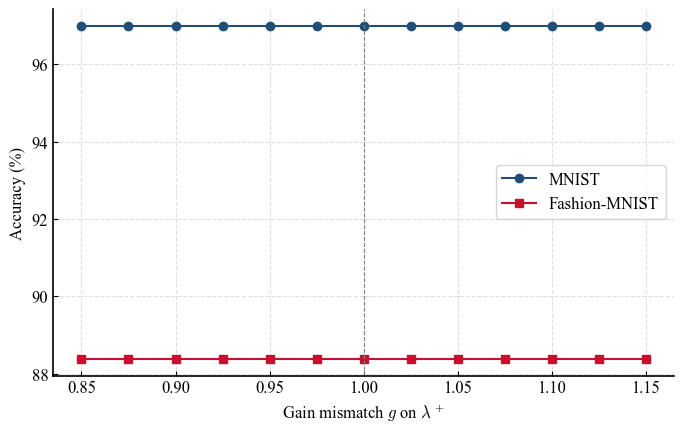

mnist: +/-5% 掉 0.00pp; +/-10% 掉 0.00pp
fashion: +/-5% 掉 0.00pp; +/-10% 掉 0.00pp


In [20]:
# ==================== Cell 20: 增益失配扫描（探测器响应度标定残差）====================
mB,_=load_model('B'); R=load_R(); gains=np.linspace(0.85,1.15,13); res={'mnist':[],'fashion':[]}
with torch.no_grad():
    for g in gains:
        for t in ['mnist','fashion']:
            wp,wn=DIFF_WL[t]['pos'],DIFF_WL[t]['neg']; c=n=0
            for imgs,labs in VAL_LOADERS[t]:
                imgs,labs=imgs.to(device),labs.to(device); amp=preprocess(imgs)
                Ip=get_det(mB,amp,wp)*g; In=get_det(mB,amp,wn)
                c+=(diff_scores(Ip,In,det_windows).argmax(1)==labs).sum().item(); n+=labs.size(0)
            res[t].append(100*c/n)
        print(f'g={g:.3f} MNIST={res["mnist"][-1]:.2f} Fashion={res["fashion"][-1]:.2f}')
save_robust('gain_mismatch_B',{'gains':[float(g) for g in gains],**res})
fig,ax=plt.subplots(figsize=(7,4.5))
ax.plot(gains,res['mnist'],'o-',color='#1F4E79',label='MNIST')
ax.plot(gains,res['fashion'],'s-',color='#C8102E',label='Fashion-MNIST')
ax.axvline(1,color='gray',ls='--',lw=.8); ax.set_xlabel(r'Gain mismatch $g$ on $\lambda^+$'); ax.set_ylabel('Accuracy (%)')
ax.legend(); ax.grid(ls='--',alpha=.4); plt.tight_layout(); savefig('supp_gain_mismatch'); plt.show()
i0=int(np.argmin(np.abs(gains-1)))
for t in ['mnist','fashion']:
    b=res[t][i0]
    w5=b-min(v for g,v in zip(gains,res[t]) if abs(g-1)<=.05+1e-9)
    w10=b-min(v for g,v in zip(gains,res[t]) if abs(g-1)<=.10+1e-9)
    print(f'{t}: +/-5% 掉 {w5:.2f}pp; +/-10% 掉 {w10:.2f}pp')


Default: MNIST=97.00 Fashion=88.38
Narrow: MNIST=97.44 Fashion=88.36
Wide: MNIST=96.97 Fashion=87.84
Cross: MNIST=97.01 Fashion=88.87
  -> robustness_results.json :: wavelength_sensitivity
  -> paper_figures/fig9_wavelength_sensitivity


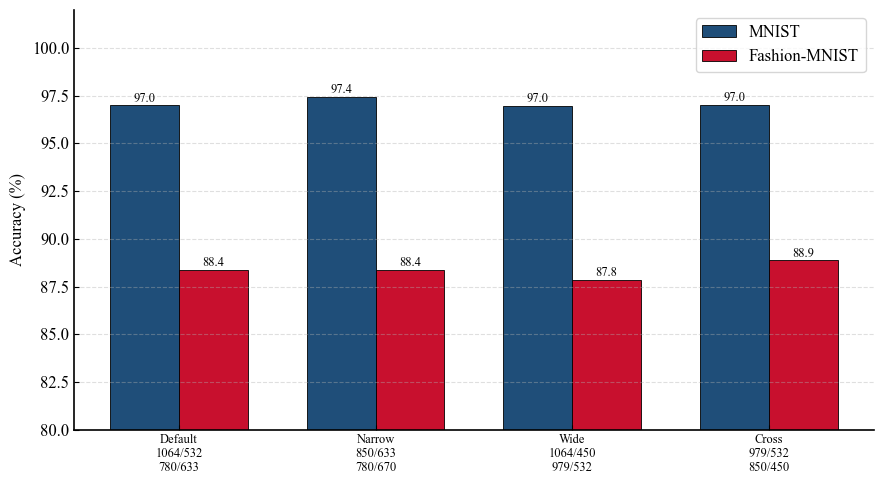

MNIST sigma=0.224  Fashion sigma=0.421


In [23]:
# ==================== Cell 21: 波长敏感性（Fig.9）====================
VAR={'Default':{'mnist':(1064e-9,532e-9),'fashion':(780e-9,633e-9)},
     'Narrow':{'mnist':(850e-9,633e-9),'fashion':(780e-9,670e-9)},
     'Wide':{'mnist':(1064e-9,450e-9),'fashion':(980e-9,532e-9)},
     'Cross':{'mnist':(980e-9,532e-9),'fashion':(850e-9,450e-9)}}
rw={}
for name,wm in VAR.items():
    sv={k:dict(v) for k,v in DIFF_WL.items()}
    try:
        DIFF_WL['mnist']={'pos':wm['mnist'][0],'neg':wm['mnist'][1]}
        DIFF_WL['fashion']={'pos':wm['fashion'][0],'neg':wm['fashion'][1]}
        wls=sorted(set(wm['mnist']+wm['fashion']))
        _,h,_,_=train_one(f'wl_{name}',1,wls,'diff',['mnist','fashion'],MAIN_SEED)
        rw[name]={'mnist_acc':float(h['mnist'][-1]),'fashion_acc':float(h['fashion'][-1]),
                  'wl_mnist':[int(w*1e9) for w in wm['mnist']],'wl_fashion':[int(w*1e9) for w in wm['fashion']]}
        print(f'{name}: MNIST={rw[name]["mnist_acc"]:.2f} Fashion={rw[name]["fashion_acc"]:.2f}')
    finally:
        DIFF_WL.clear(); DIFF_WL.update(sv)
save_robust('wavelength_sensitivity',rw)
names=list(rw); mv=[rw[v]['mnist_acc'] for v in names]; fv=[rw[v]['fashion_acc'] for v in names]
x=np.arange(len(names)); w=.35; fig,ax=plt.subplots(figsize=(9,5))
ax.bar(x-w/2,mv,w,color='#1F4E79',label='MNIST',edgecolor='k',lw=.6)
ax.bar(x+w/2,fv,w,color='#C8102E',label='Fashion-MNIST',edgecolor='k',lw=.6)
for i,(a,b) in enumerate(zip(mv,fv)):
    ax.text(i-w/2,a+.2,f'{a:.1f}',ha='center',fontsize=9); ax.text(i+w/2,b+.2,f'{b:.1f}',ha='center',fontsize=9)
ax.set_xticks(x); ax.set_xticklabels([f"{n}\n{rw[n]['wl_mnist'][0]}/{rw[n]['wl_mnist'][1]}\n{rw[n]['wl_fashion'][0]}/{rw[n]['wl_fashion'][1]}" for n in names],fontsize=9)
ax.set_ylabel('Accuracy (%)'); ax.set_ylim(80,102); ax.legend(); ax.grid(axis='y',ls='--',alpha=.4)
plt.tight_layout(); savefig('fig9_wavelength_sensitivity'); plt.show()
print(f"MNIST sigma={np.std(mv,ddof=1):.3f}  Fashion sigma={np.std(fv,ddof=1):.3f}")


## 6. 生成开源材料（README + requirements）

In [22]:
# ==================== Cell 22: 写 README / requirements ====================
import torch, torchvision, numpy, matplotlib, sklearn, sys
req = f'''torch=={torch.__version__.split("+")[0]}
torchvision=={torchvision.__version__.split("+")[0]}
numpy=={numpy.__version__}
matplotlib=={matplotlib.__version__}
scikit-learn=={sklearn.__version__}
'''
open('requirements.txt','w',encoding='utf-8').write(req)

readme = f'''# Multi-task Optical Classification with Single-layer Differential D2NN

Code and trained models reproducing all results of the paper.

## Environment
Python {sys.version.split()[0]}; install deps:
```
pip install -r requirements.txt
```
Datasets (MNIST / Fashion-MNIST / EMNIST-Letters / USPS) download automatically via torchvision on first run.

## Reproduce
Open `d2nn_full_experiments.ipynb`, run `Kernel -> Restart & Run All`.
- Trained models: `saved_models/<config>_seed<seed>.pt`
- To reproduce Table 1 without retraining, load a checkpoint:
```python
ck = torch.load('saved_models/B_seed42.pt', weights_only=False)
```
- Figures regenerate into `paper_figures/` from the saved models and `all_results.json`.

## Protocol
- Fixed 30 epochs, Adam lr=0.005, StepLR(5,0.5), batch 32/task, no early stopping, no validation-based selection.
- Reported accuracy = blind test accuracy of the final-epoch model on the standard test sets.
- Multi-task training cycles the smaller datasets so each task gets equal gradient steps per epoch.
- T=0.1, energy weight lambda_E=1e-3, epsilon=1e-6; single layer = {N_PIXELS*N_PIXELS} parameters.
- Wavelength pairs (nm): MNIST 1064/532, Fashion 780/633, EMNIST 850/450, USPS 980/488.
- EMNIST uses the 10-class A-J subset to share the 10-window detector layout.

## Files
- `all_results.json` — accuracies & training histories, all configs & seeds
- `robustness_results.json` — noise / fabrication / gain / wavelength scans
- `height_profile_B_seed42_um.npy` — optimized DOE height map (micron)
- `saved_samples/` — detector-plane intensities for Fig. 2

## License
Code: MIT. Datasets belong to their respective owners.
'''
open('README.md','w',encoding='utf-8').write(readme)
print('已生成 README.md 和 requirements.txt')
print('\n开源清单：')
for f in ['d2nn_full_experiments.ipynb','all_results.json','robustness_results.json',
          'height_profile_B_seed42_um.npy','README.md','requirements.txt']:
    print(f'  [{"Y" if os.path.exists(f) else " "}] {f}')
for dname in ['saved_models','saved_samples','paper_figures']:
    n=len(os.listdir(dname)) if os.path.isdir(dname) else 0
    print(f'  [{"Y" if n else " "}] {dname}/  ({n} files)')


已生成 README.md 和 requirements.txt

开源清单：
  [ ] d2nn_full_experiments.ipynb
  [Y] all_results.json
  [Y] robustness_results.json
  [Y] height_profile_B_seed42_um.npy
  [Y] README.md
  [Y] requirements.txt
  [Y] saved_models/  (41 files)
  [Y] saved_samples/  (8 files)
  [Y] paper_figures/  (22 files)
